In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# 1. Load the real California Housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 2. Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Instantiate the DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)

# 4. Fit the model to the training data
print("Training the Decision Tree model...")
dt_model.fit(X_train, y_train)

# 5. Generate predictions for the test set
dt_predictions = dt_model.predict(X_test)

print("Decision Tree training and prediction complete.")

Training the Decision Tree model...
Decision Tree training and prediction complete.


## Evaluate and Compare Metrics

### Subtask:
Calculate performance metrics (MSE, MAE, RMSE, and R2) for the Decision Tree model and compare them with the Random Forest results.


**Reasoning**:
I will calculate the performance metrics for the Decision Tree model using the predictions and actual values, then compare them with the previously calculated Random Forest metrics as instructed.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Calculate metrics for Decision Tree
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

# 2. Compute RMSE
dt_rmse = np.sqrt(dt_mse)

# 3 & 4. Summary and Comparison
print("--- Model Comparison ---")
print(f"{'Metric':<10} | {'Random Forest':<15} | {'Decision Tree':<15}")
print("-" * 45)
# Using the values provided in the instructions for Random Forest
print(f"{'MSE':<10} | {0.2573:<15.4f} | {dt_mse:<15.4f}")
print(f"{'MAE':<10} | {0.3303:<15.4f} | {dt_mae:<15.4f}")
print(f"{'RMSE':<10} | {0.5072:<15.4f} | {dt_rmse:<15.4f}")
print(f"{'R2 Score':<10} | {0.8037:<15.4f} | {dt_r2:<15.4f}")

--- Model Comparison ---
Metric     | Random Forest   | Decision Tree  
---------------------------------------------
MSE        | 0.2573          | 0.4952         
MAE        | 0.3303          | 0.4547         
RMSE       | 0.5072          | 0.7037         
R2 Score   | 0.8037          | 0.6221         


Loading data...
Training the Random Forest model...

Model Results:
MSE: 0.2572979293772426
MAE: 0.33033297364341085
RMSE: 0.5072454330767726
R-squared Score: 0.8036506665860602


/tmp/ipykernel_1691/1982435234.py:42: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')


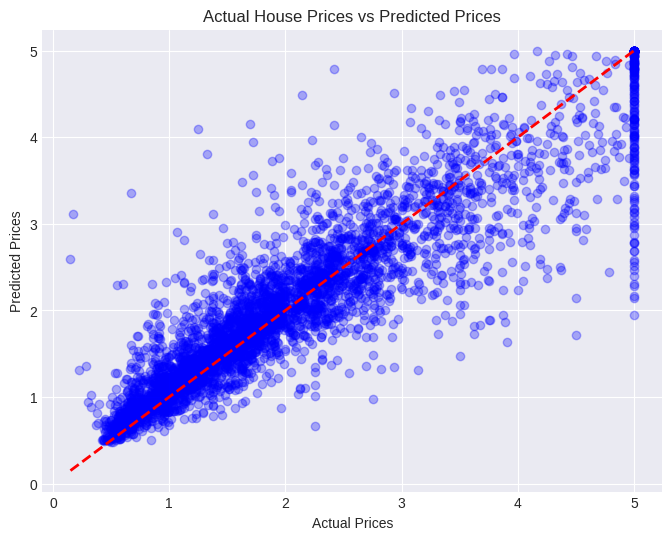

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the real California Housing dataset
print("Loading data...")
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 2. Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and train the model
print("Training the Random Forest model...")
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# 4. Make predictions
predictions = model.predict(X_test)

# 5. Calculate errors
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mse)

# 6. Calculate the performance metric for regression
r2 = r2_score(y_test, predictions)

print("\nModel Results:")
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R-squared Score:", r2)

# 7. Plot the graph
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.3, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')
plt.title('Actual House Prices vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

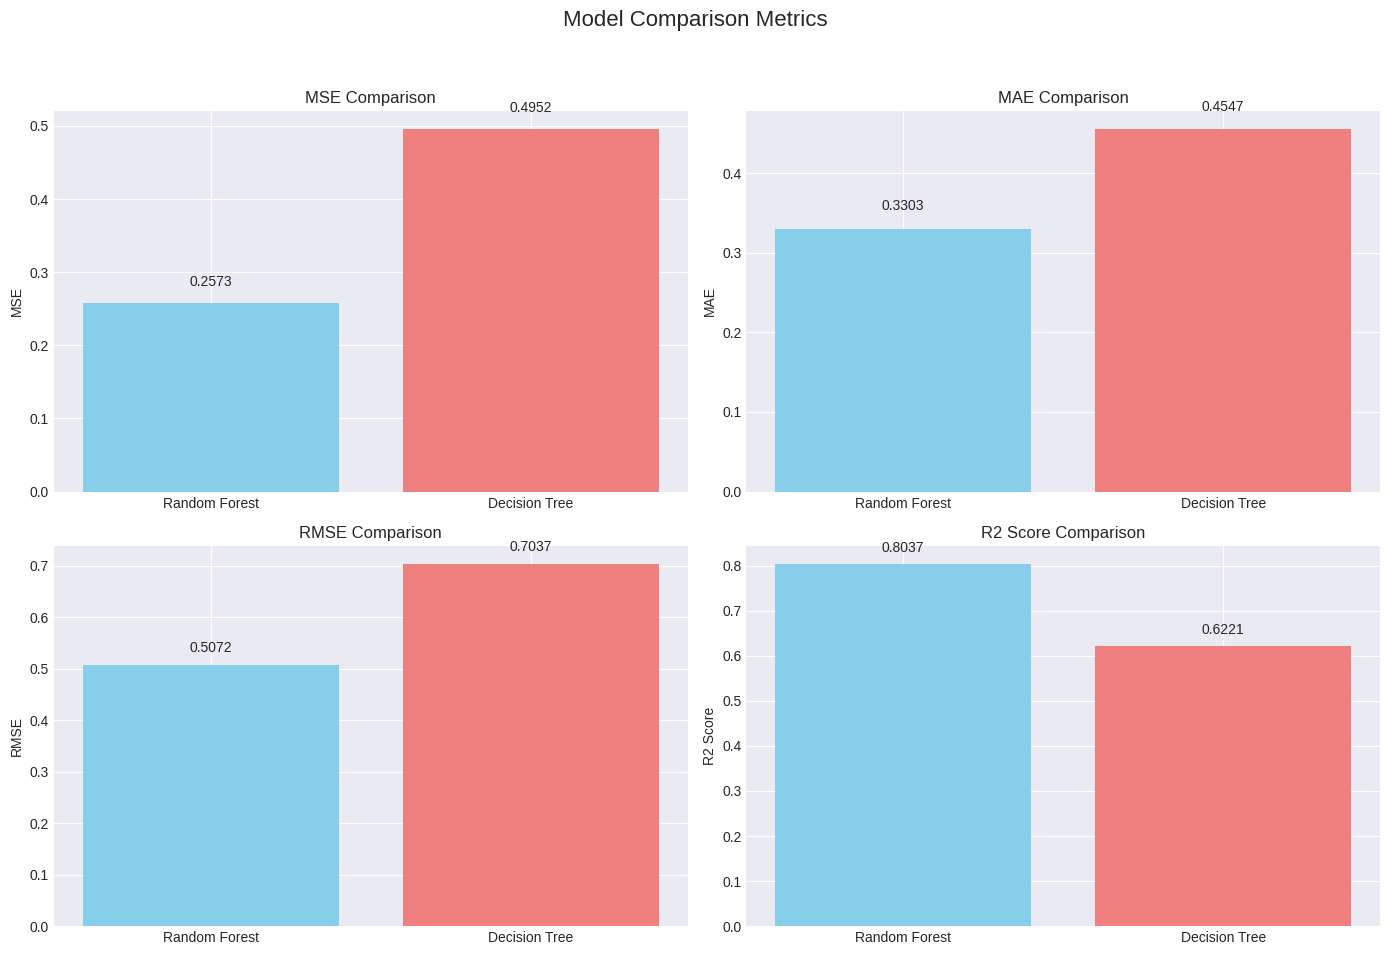

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data from the previous comparison table
metrics_data = {
    'Metric': ['MSE', 'MAE', 'RMSE', 'R2 Score'],
    'Random Forest': [0.2573, 0.3303, 0.5072, 0.8037],
    'Decision Tree': [0.4952, 0.4547, 0.7037, 0.6221]
}

df_metrics = pd.DataFrame(metrics_data)

# Set the aesthetic style of the plots
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison Metrics', fontsize=16)

metrics = ['MSE', 'MAE', 'RMSE', 'R2 Score']

for i, metric in enumerate(metrics):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    metric_df = df_metrics[df_metrics['Metric'] == metric]

    model_names = ['Random Forest', 'Decision Tree']
    values = [metric_df['Random Forest'].iloc[0], metric_df['Decision Tree'].iloc[0]]
    colors = ['skyblue', 'lightcoral']

    bars = ax.bar(model_names, values, color=colors)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_ylim(bottom=0) # Ensure y-axis starts from 0 for fair comparison

    # Add value labels on top of the bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 4), ha='center', va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()